In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [44]:
import os
print(os.getcwd())

c:\Users\regmi\OneDrive\Desktop\Telecom_Customer_Churn_G6\Predictive_Modeling


In [45]:
import os
os.listdir("../Data_Preparation")

['processed_data', 'Raw_Data', 'README.md']

In [46]:
os.listdir("../Data_Preparation/processed_data")

['preprocessed_telecom_churn.csv',
 'README.md',
 'X_test.csv',
 'X_train.csv',
 'y_test.csv',
 'y_train.csv']

In [47]:
import pandas as pd

X_train = pd.read_csv("../Data_Preparation/processed_data/X_train.csv")
X_test = pd.read_csv("../Data_Preparation/processed_data/X_test.csv")

y_train = pd.read_csv("../Data_Preparation/processed_data/y_train.csv")
y_test = pd.read_csv("../Data_Preparation/processed_data/y_test.csv")

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (5634, 13)
Test shape: (1409, 13)


In [48]:
import pandas as pd

X_train = pd.read_csv("../Data_Preparation/processed_data/X_train.csv")
X_test = pd.read_csv("../Data_Preparation/processed_data/X_test.csv")

y_train = pd.read_csv("../Data_Preparation/processed_data/y_train.csv")
y_test = pd.read_csv("../Data_Preparation/processed_data/y_test.csv")

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (5634, 13)
Test shape: (1409, 13)


In [49]:
model = Sequential()

model.add(Dense(16, activation='relu', input_dim=X_train.shape[1]))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer=Adam(),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

c:\Users\regmi\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 369 (1.44 KB)

 Trainable params: 369 (1.44 KB)

 Non-trainable params: 0 (0.00 B)

In [50]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7597 - loss: 0.4999 - val_accuracy: 0.7750 - val_loss: 0.4742
Epoch 2/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7819 - loss: 0.4552 - val_accuracy: 0.7821 - val_loss: 0.4640
Epoch 3/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7847 - loss: 0.4488 - val_accuracy: 0.7779 - val_loss: 0.4623
Epoch 4/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7888 - loss: 0.4461 - val_accuracy: 0.7850 - val_loss: 0.4578
Epoch 5/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7872 - loss: 0.4437 - val_accuracy: 0.7850 - val_loss: 0.4575
Epoch 6/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7874 - loss: 0.4422 - val_accuracy: 0.7835 - val_loss: 0.4552
Epoch 7/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7890 - loss: 0.4406 - val_accuracy: 0.7828 - val_loss: 0.4543
Epoch 8/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7914 - loss: 0.4393 - val_accuracy: 0.

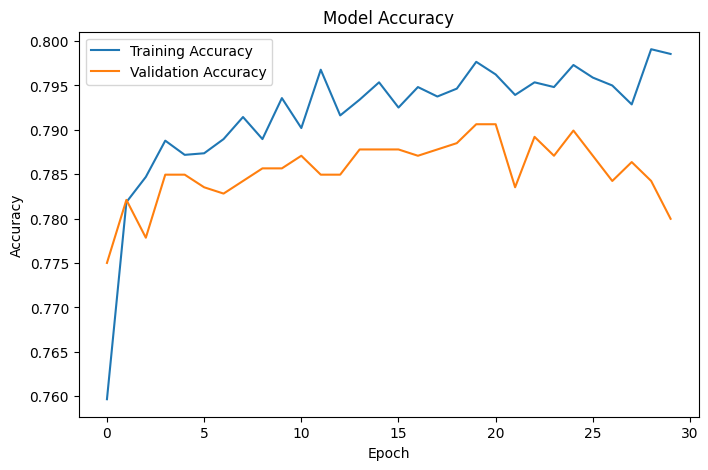

In [51]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

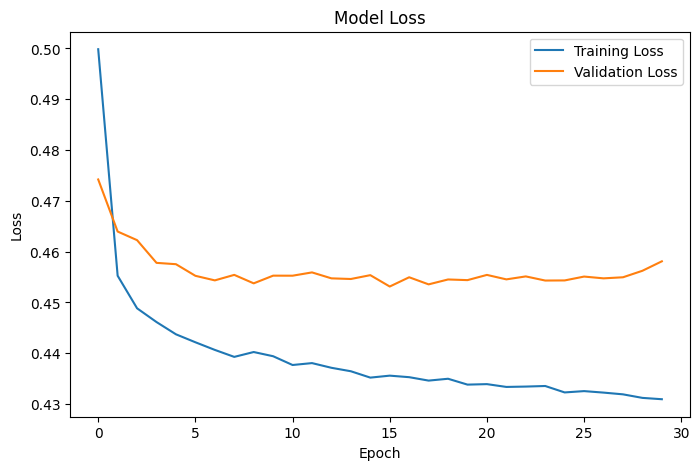

In [52]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


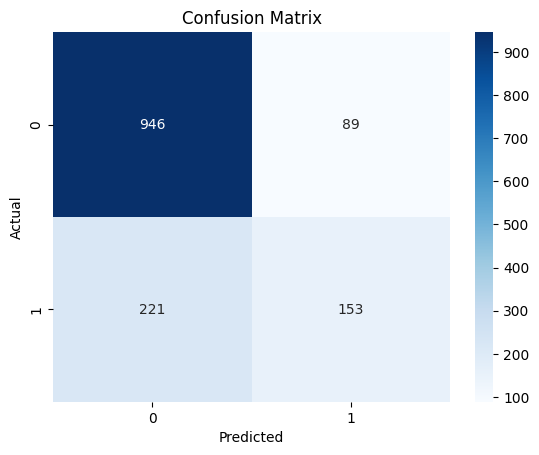

In [53]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [54]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.91      0.86      1035
           1       0.63      0.41      0.50       374

    accuracy                           0.78      1409
   macro avg       0.72      0.66      0.68      1409
weighted avg       0.76      0.78      0.76      1409



In [55]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.91      0.86      1035
           1       0.63      0.41      0.50       374

    accuracy                           0.78      1409
   macro avg       0.72      0.66      0.68      1409
weighted avg       0.76      0.78      0.76      1409

